# Import

In [1]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
import sys, os
sys.path.append(os.path.abspath(".."))

from src.preprocessing import load_dataset, build_gene_matrix
from src.gradcam_utils import (
    make_grad_heatmap, display_gradcam_with_img,
    compute_group_heatmap, compute_difference_heatmap, resize_and_normalize_heatmap,
    plot_heatmap_with_max_region, plot_heatmap_diff,
    plot_diff_heatmap_with_top_genes,
    get_gene_pathway_from_position, get_top_n_bright_spots, find_gene_position,
    get_top_positive_diff_spots, get_top_negative_diff_spots,
    plot_diff_heatmap_subset
)

/home/taejoon/mount_ssd2/2023/scRNA/venv_scrna/lib/python3.9/site-packages/pandas/compat/__init__.py:124: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


# Load data

In [2]:
# Numpy 배열 불러오기 
X_responder = np.load("../data/npy/X_responder.npy")
y_responder = np.load("../data/npy/y_responder.npy")
X_nonresponder = np.load("../data/npy/X_nonresponder.npy")
y_nonresponder = np.load("../data/npy/y_nonresponder.npy")

print("Responder:", X_responder.shape, "Non-responder:", X_nonresponder.shape)

# gene x pathway 
dataset_path = "../data/dataset.csv"
X, y = load_dataset(dataset_path)
with open("../data/pathway_list.pkl", "rb") as f:
    pathway_list = pickle.load(f)   
with open("../data/cell_list.pkl", "rb") as f:
    cell_list = pickle.load(f)   
    
gene_matrix = build_gene_matrix(X, pathway_list=pathway_list, cell_list=cell_list, max_genes=383)

Responder: (5564, 383, 186) Non-responder: (10726, 383, 186)


# Load 2D CNN Model

In [3]:
# 학습된 2D CNN 모델 로드
model_cnn2d = keras.models.load_model("../models/cnn2d_best.h5")

2025-09-24 02:07:20.844613: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 02:07:21.307169: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22401 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2025-09-24 02:07:21.307856: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22416 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6


In [4]:
model_cnn2d.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 383, 186, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 383, 186, 128)     1280      
                                                                 
 activation (Activation)     (None, 383, 186, 128)     0         
                                                                 
 dropout (Dropout)           (None, 383, 186, 128)     0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 191, 93, 128)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 191, 93, 32)       36896     
                                                             

In [5]:
last_conv_layer_name = "max_pooling2d_2"  

# Grad-CAM

## Responder heatmap

  0%|                                                                                                                                   | 0/5564 [00:00<?, ?it/s]2025-09-24 02:07:21.821377: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8907
2025-09-24 02:07:22.810240: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5564/5564 [00:59<00:00, 93.11it/s]


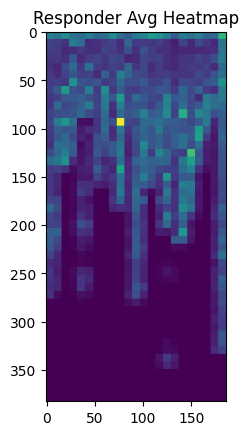

In [6]:
res_heatmap = compute_group_heatmap(X_responder, model_cnn2d, last_conv_layer_name)
res_heatmap = resize_and_normalize_heatmap(res_heatmap, target_shape=(383,186))
plt.imshow(res_heatmap, cmap="viridis"); plt.title("Responder Avg Heatmap"); plt.show()

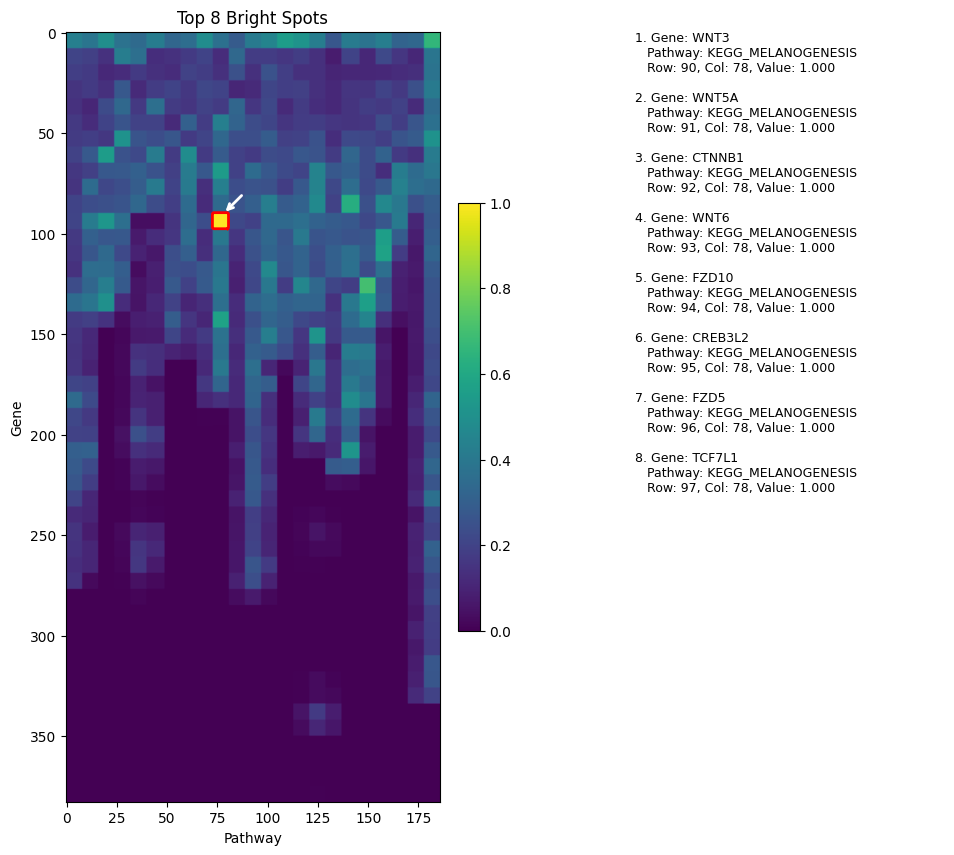

In [7]:
top_spots_res = plot_heatmap_with_max_region(
    res_heatmap,
    gene_matrix,
    pathway_list,
    top_n=8
)

## Non-responder heatmap

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10726/10726 [01:52<00:00, 95.33it/s]


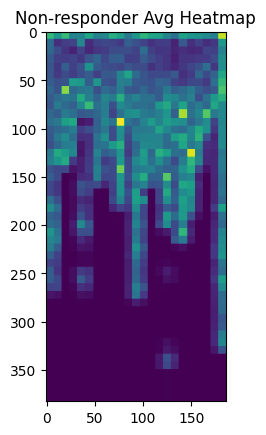

In [8]:
non_heatmap = compute_group_heatmap(X_nonresponder, model_cnn2d, last_conv_layer_name)
non_heatmap = resize_and_normalize_heatmap(non_heatmap, target_shape=(383,186))
plt.imshow(non_heatmap, cmap="viridis"); plt.title("Non-responder Avg Heatmap"); plt.show()

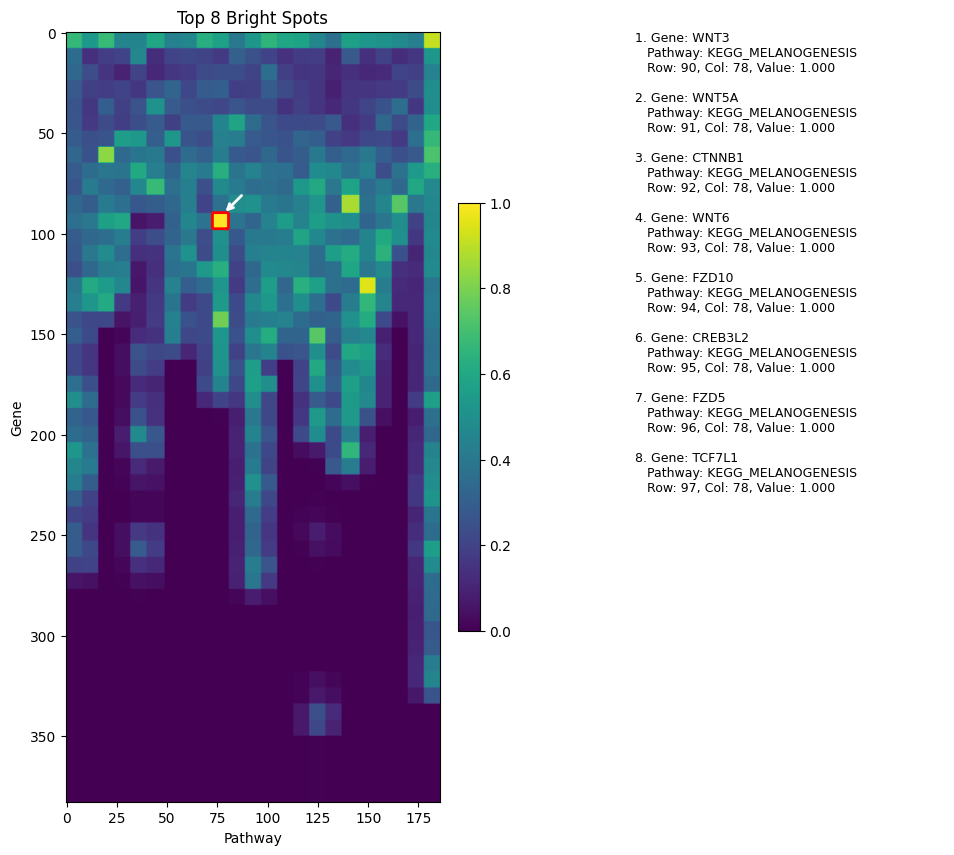

In [9]:
top_spots_nonres = plot_heatmap_with_max_region(
    non_heatmap,
    gene_matrix,
    pathway_list,
    top_n=8
)

## Difference

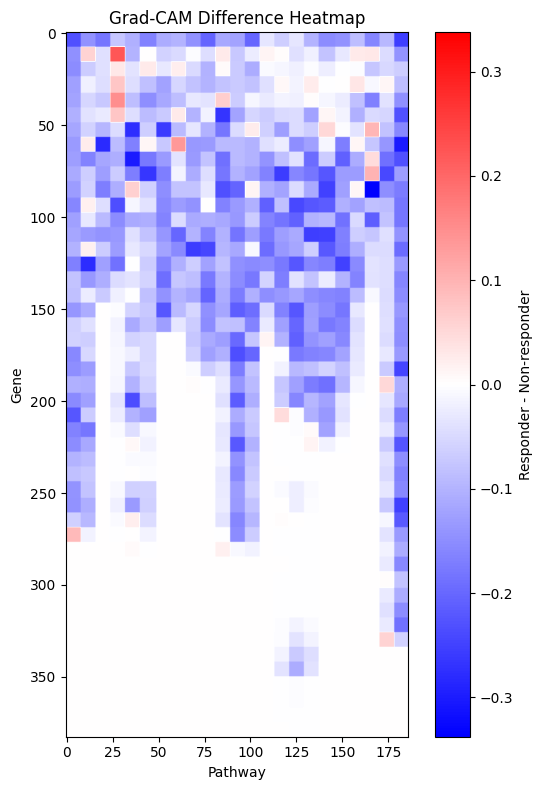

In [10]:
heatmap_diff = plot_heatmap_diff(res_heatmap, non_heatmap)

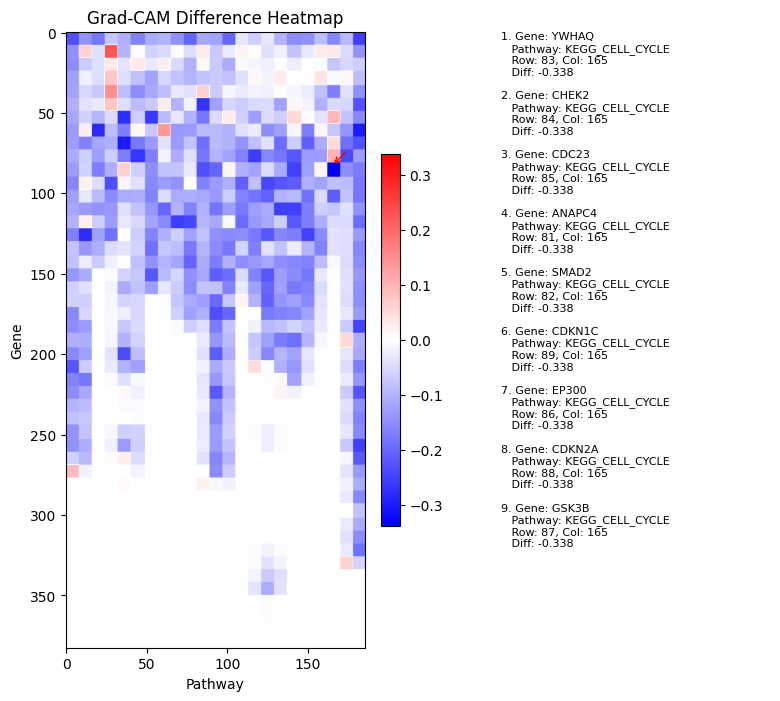

In [14]:
top_diff = plot_diff_heatmap_with_top_genes(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_n=9
)

## Responder > Non-responder

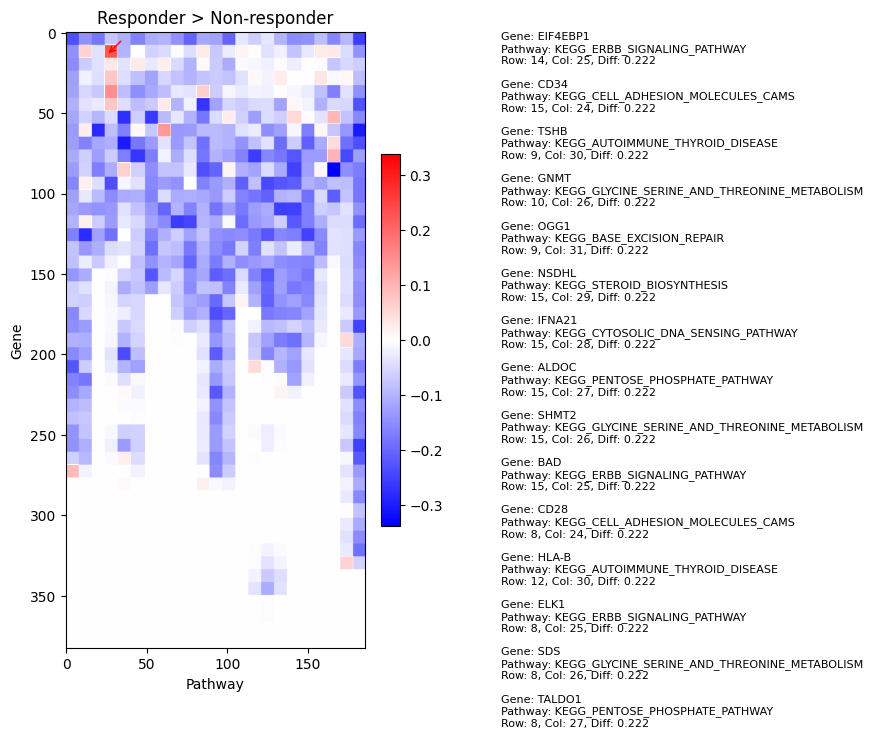

In [17]:
top_pos = get_top_positive_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=15)
plot_diff_heatmap_subset(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_pos,
    title="Responder > Non-responder"
)

## Non-responder > Responder

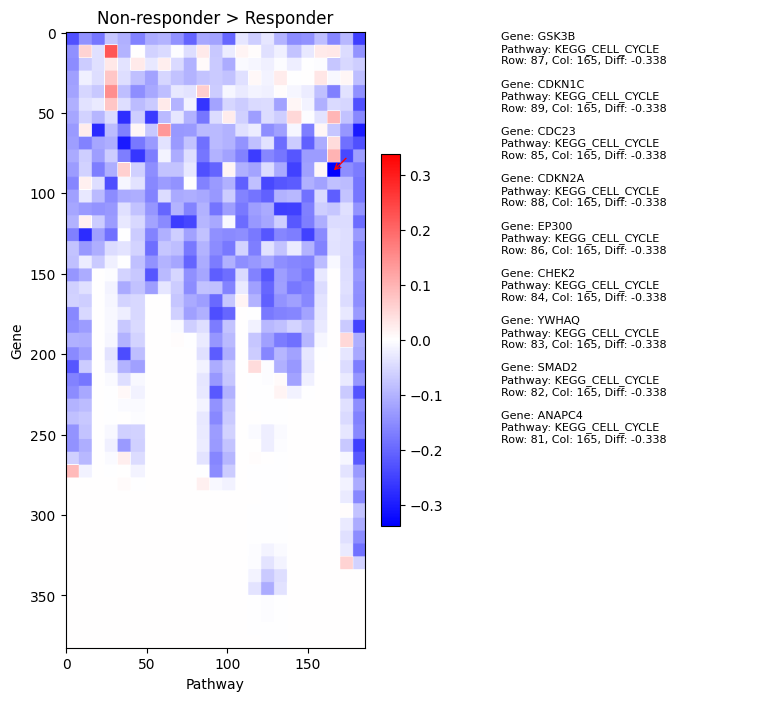

In [16]:
# Non-responder 강조 (음수 차이)
top_neg = get_top_negative_diff_spots(heatmap_diff, gene_matrix, pathway_list, top_n=9)
plot_diff_heatmap_subset(
    heatmap_diff,
    gene_matrix,
    pathway_list,
    top_neg,
    title="Non-responder > Responder"
)